# Auditoría de anotaciones con `detr_t10_logmel`

Sobre val: recall con y sin clase, punto de operación por recall objetivo, y qué son los
falsos positivos: cuántos están junto a una anotación de su misma clase, en su misma banda.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile
import torch
import torchaudio
from matplotlib.axes import Axes
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from torch import Tensor
from torchvision.ops import box_convert

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR / "src"))

from core.config import NMS_IOU, RUNS_DIR, P  # noqa: E402
from data import cache  # noqa: E402
from data.species import LabelSet, split_label  # noqa: E402
from evaluation.evaluator import RawPredictions, path_for  # noqa: E402
from evaluation.metrics import (  # noqa: E402
    MATCH_IOU,
    Boxes,
    assignments,
    hits,
    overlaps,
    rows_by_image,
)
from evaluation.protocol import (  # noqa: E402
    THRESHOLD_GRID,
    Matched,
    Point,
    equalize,
    match,
    operating_point,
    select,
)
from utils.audio import mel_spectrogram, mel_to_unit  # noqa: E402
from utils.boxes import suppress_nested  # noqa: E402

RUN = "detr_t10_logmel"
MIN_PRECISION = 0.70
TARGET_RECALL = 0.90
GAP_S = 0.5
SYLLABLES = ("lw/cs", "sm/fs")
NEARBY, SAME_SPECIES, OTHER_SPECIES, ISOLATED = (
    "junto a otra de su clase",
    "junto a su especie",
    "junto a otra especie",
    "aislada",
)
CATEGORIES = [NEARBY, SAME_SPECIES, OTHER_SPECIES, ISOLATED]
COLORS = dict(zip(CATEGORIES, ["#1baf7a", "#2a78d6", "#eda100", "#8a8a8a"], strict=True))
SERIES_GAPS_S = (0.5, 1.0, 2.0, 5.0)
WITH_CLASS, WITH_SPECIES, OVER_OTHER, UNANNOTATED = (
    "en serie con su clase",
    "en serie con su especie",
    "serie sobre otra especie",
    "serie sin anotar",
)
SERIES_CATEGORIES = [WITH_CLASS, WITH_SPECIES, OVER_OTHER, UNANNOTATED, ISOLATED]
SERIES_COLORS = dict(
    zip(SERIES_CATEGORIES, ["#1baf7a", "#2a78d6", "#eda100", "#d03b3b", "#8a8a8a"], strict=True)
)
OVERLAP_IOU = 0.1
MAX_SEGMENT_S = 15.0
pd.set_option("display.width", 140)

In [2]:
dump = RawPredictions.load(path_for(RUNS_DIR / RUN, RUN, cache.VAL))
labels = LabelSet(dump.labels)
predictions = equalize(dump.predictions)
truth = dump.truth
print(
    f"{dump.n_images} ventanas · {len(truth.boxes)} cajas anotadas · "
    f"{len(predictions.boxes)} predicciones"
)

9520 ventanas · 10126 cajas anotadas · 952000 predicciones


In [3]:
def agnostic(boxes: Boxes) -> Boxes:
    return boxes._replace(labels=torch.zeros_like(boxes.labels))


def curve(matched: Matched) -> pd.DataFrame:
    return pd.DataFrame([operating_point(matched, t)._asdict() for t in THRESHOLD_GRID])


def select_recall(matched: Matched, min_recall: float) -> Point | None:
    points = [operating_point(matched, t) for t in THRESHOLD_GRID]
    feasible = [p for p in points if p.recall is not None and p.recall >= min_recall]
    if not feasible:
        return None
    return max(feasible, key=lambda p: (p.precision or 0.0, p.recall or 0.0))


matched = match(predictions, truth, dump.n_images)
matched_agnostic = match(agnostic(predictions), agnostic(truth), dump.n_images)
matchings = {"por clase": matched, "sin clase": matched_agnostic}
curves = {name: curve(m) for name, m in matchings.items()}
points = pd.DataFrame(
    [
        {"emparejamiento": name, "criterio": criterion, **point._asdict()}
        for name, m in matchings.items()
        for criterion, point in (
            (f"P ≥ {MIN_PRECISION:.2f}", select(m, MIN_PRECISION)),
            (f"R ≥ {TARGET_RECALL:.2f}", select_recall(m, TARGET_RECALL)),
        )
        if point is not None
    ]
)
points.round(3)

,emparejamiento,criterio,threshold,recall,precision,n_above,n_tp
0,por clase,P ≥ 0.70,0.34,0.747,0.707,10704,7563
1,por clase,R ≥ 0.90,0.10,0.905,0.217,42206,9159
2,sin clase,P ≥ 0.70,0.33,0.767,0.707,10989,7767
3,sin clase,R ≥ 0.90,0.13,0.904,0.298,30708,9152


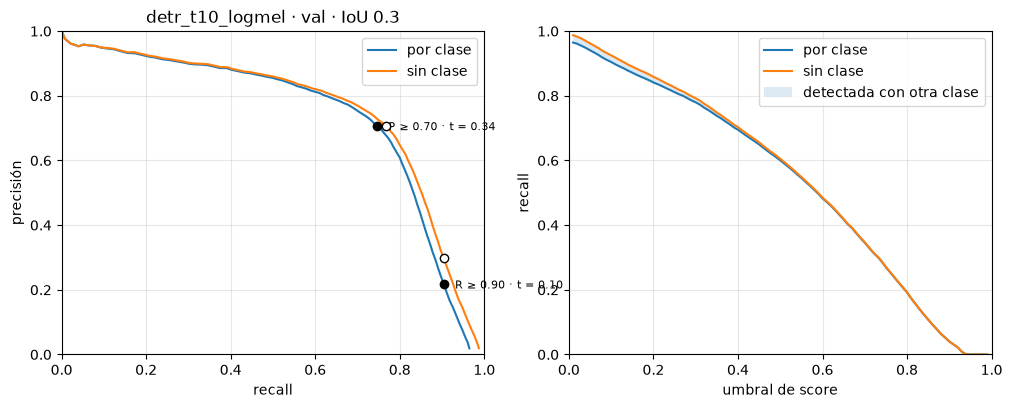

In [4]:
fig, (left, right) = plt.subplots(1, 2, figsize=(12, 4.2))
for name, table in curves.items():
    left.plot(table.recall, table.precision, label=name)
    right.plot(table.threshold, table.recall, label=name)
for row in points.to_dict("records"):
    by_class_point = row["emparejamiento"] == "por clase"
    left.scatter(
        row["recall"],
        row["precision"],
        s=36,
        color="black" if by_class_point else "white",
        edgecolor="black",
        zorder=3,
    )
    if by_class_point:
        left.annotate(
            f"{row['criterio']} · t = {row['threshold']:.2f}",
            (row["recall"], row["precision"]),
            textcoords="offset points",
            xytext=(8, -3),
            fontsize=8,
        )
by_class, agnostic_curve = curves["por clase"], curves["sin clase"]
right.fill_between(
    by_class.threshold,
    by_class.recall,
    agnostic_curve.recall,
    alpha=0.15,
    label="detectada con otra clase",
)
left.set(xlabel="recall", ylabel="precisión", xlim=(0, 1), ylim=(0, 1))
left.set_title(f"{RUN} · val · IoU {MATCH_IOU}")
right.set(xlabel="umbral de score", ylabel="recall", xlim=(0, 1), ylim=(0, 1))
for ax in (left, right):
    ax.grid(alpha=0.3)
    ax.legend()
plt.show()

In [5]:
operating = select(matched, MIN_PRECISION)
assert operating is not None
threshold = operating.threshold
n_above = matched.above(threshold)
kept = predictions.select(torch.arange(n_above))
found = matched.found[:n_above] == 1

pairs = assignments(overlaps(kept, truth, class_aware=False), MATCH_IOU)
pair_rows = torch.tensor([p for p, _ in pairs], dtype=torch.long)
pair_truth = torch.tensor([t for _, t in pairs], dtype=torch.long)
confusion = pd.DataFrame(
    {
        "anotada": [labels.name(i) for i in truth.labels[pair_truth].tolist()],
        "predicha": [labels.name(i) for i in kept.labels[pair_rows].tolist()],
    }
)
confusion["misma clase"] = confusion.anotada == confusion.predicha
confusion["misma especie"] = [
    split_label(a)[0] == split_label(p)[0]
    for a, p in zip(confusion.anotada, confusion.predicha, strict=True)
]

n_truth = pd.Series(truth.labels.tolist()).value_counts()
recall_table = pd.DataFrame(
    {
        "anotadas": n_truth,
        "sin clase": pd.Series(truth.labels[pair_truth].tolist()).value_counts() / n_truth,
        "por clase": pd.Series(kept.labels[found].tolist()).value_counts() / n_truth,
    }
).fillna(0.0)
recall_table.index = pd.Index([labels.name(i) for i in recall_table.index])
recall_table = recall_table.sort_values("anotadas", ascending=False)

print(
    f"umbral {threshold:.2f} · recall sin clase {len(pairs) / len(truth.boxes):.2f} · "
    f"por clase {operating.recall:.2f} · de lo detectado: clase correcta "
    f"{confusion['misma clase'].mean():.2f}, especie correcta {confusion['misma especie'].mean():.2f}"
)
recall_table.round(2)

umbral 0.34 · recall sin clase 0.76 · por clase 0.75 · de lo detectado: clase correcta 0.99, especie correcta 1.00


,anotadas,sin clase,por clase
as/hc,2599,0.87,0.87
ac/bc,1082,0.84,0.84
lw/cs,1000,0.87,0.87
sm/cc,884,0.72,0.72
as/bc,837,0.59,0.57
pt/dc,730,0.88,0.88
sb/ppc,530,0.57,0.54
aa/gc,346,0.86,0.85
sb/spc,322,0.34,0.33
sm/fs,298,0.63,0.57


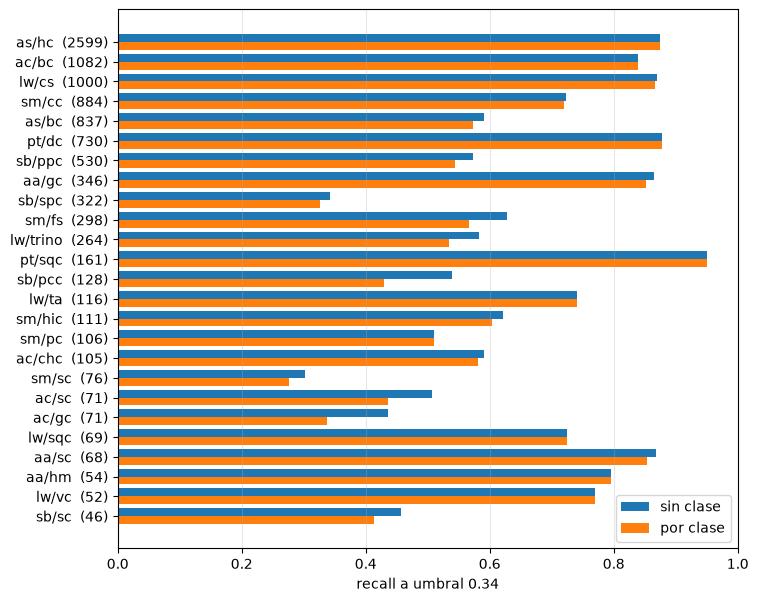

In [6]:
fig, ax = plt.subplots(figsize=(8, 7))
order = recall_table.index[::-1]
y = np.arange(len(order))
ax.barh(y + 0.2, recall_table.loc[order, "sin clase"], height=0.4, label="sin clase")
ax.barh(y - 0.2, recall_table.loc[order, "por clase"], height=0.4, label="por clase")
ax.set_yticks(y, [f"{name}  ({int(recall_table.loc[name, 'anotadas'])})" for name in order])
ax.set(xlim=(0, 1), xlabel=f"recall a umbral {threshold:.2f}")
ax.grid(axis="x", alpha=0.3)
ax.legend(loc="lower right")
plt.show()

In [7]:
def time_gap_s(inner: Tensor, outer: Tensor) -> Tensor:
    a = box_convert(inner, "cxcywh", "xyxy")
    b = box_convert(outer, "cxcywh", "xyxy")
    gap = torch.max(a[:, None, 0], b[None, :, 0]) - torch.min(a[:, None, 2], b[None, :, 2])
    same_band = torch.min(a[:, None, 3], b[None, :, 3]) > torch.max(a[:, None, 1], b[None, :, 1])
    return (gap.clamp(min=0) * P.clip_len_s).masked_fill(~same_band, float("inf"))


def categorize(name: str, neighbours: list[str]) -> str:
    species = split_label(name)[0]
    if name in neighbours:
        return NEARBY
    if any(split_label(n)[0] == species for n in neighbours):
        return SAME_SPECIES
    return OTHER_SPECIES if neighbours else ISOLATED


def audit_false_positives(false_positives: Boxes, kept_rows: Tensor) -> pd.DataFrame:
    truth_rows = rows_by_image(truth.image_ids)
    records = []
    for row, image_id in enumerate(false_positives.image_ids.tolist()):
        name = labels.name(int(false_positives.labels[row]))
        candidates = truth_rows.get(image_id, [])
        gaps = time_gap_s(false_positives.boxes[row : row + 1], truth.boxes[candidates])[0]
        neighbours = [
            labels.name(int(truth.labels[c]))
            for c, near in zip(candidates, (gaps <= GAP_S).tolist(), strict=True)
            if near
        ]
        records.append(
            {
                "fila": int(kept_rows[row]),
                "ventana": image_id,
                "grabación": dump.recording_names[int(dump.recordings[image_id])],
                "clase": name,
                "score": float(false_positives.scores[row]),
                "categoría": categorize(name, neighbours),
                "junto a": ", ".join(sorted(set(neighbours))) or None,
            }
        )
    return pd.DataFrame(records)


false_positive_rows = torch.arange(n_above)[~found]
false_positives = kept.select(false_positive_rows)
audit = audit_false_positives(false_positives, false_positive_rows)
summary = audit["categoría"].value_counts().reindex(CATEGORIES, fill_value=0).to_frame("FP")
summary["%"] = (100 * summary.FP / summary.FP.sum()).round(1)
summary["score mediano"] = audit.groupby("categoría").score.median().reindex(CATEGORIES).round(2)
print(f"{len(false_positives.boxes)} FP y {operating.n_tp} TP a umbral {threshold:.2f}")
summary

3141 FP y 7563 TP a umbral 0.34


,FP,%,score mediano
categoría,,,
junto a otra de su clase,563,17.9,0.44
junto a su especie,381,12.1,0.45
junto a otra especie,124,3.9,0.45
aislada,2073,66.0,0.50


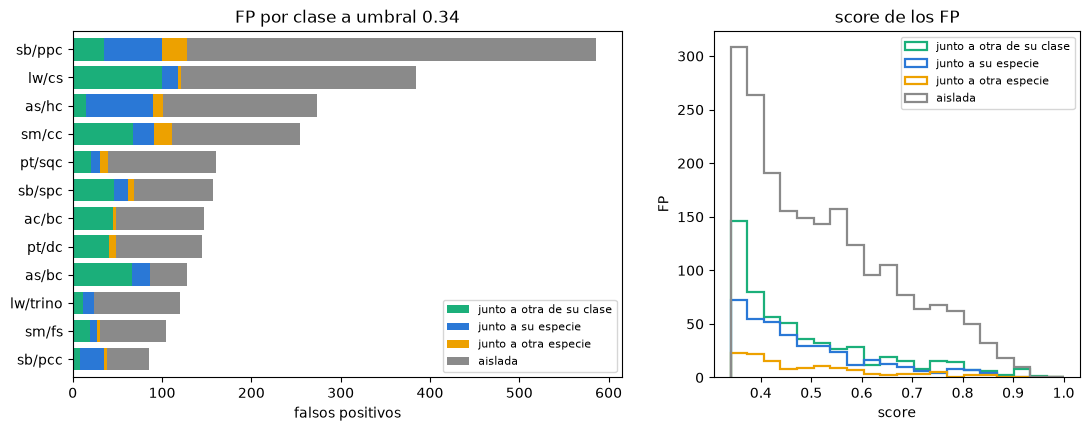

In [8]:
per_class = pd.crosstab(audit.clase, audit["categoría"]).reindex(columns=CATEGORIES, fill_value=0)
per_class = per_class.loc[per_class.sum(axis=1).sort_values(ascending=False).index[:12]]

fig, (left, right) = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [3, 2]})
per_class.iloc[::-1].plot.barh(
    stacked=True, ax=left, color=[COLORS[c] for c in CATEGORIES], width=0.8
)
left.set(xlabel="falsos positivos", ylabel="")
left.set_title(f"FP por clase a umbral {threshold:.2f}")
left.legend(fontsize=8)
bins = np.linspace(threshold, 1.0, 21)
for category in CATEGORIES:
    right.hist(
        audit.score[audit["categoría"] == category],
        bins=bins,
        histtype="step",
        lw=1.6,
        color=COLORS[category],
        label=category,
    )
right.set(xlabel="score", ylabel="FP")
right.set_title("score de los FP")
right.legend(fontsize=8)
plt.show()

In [9]:
OFFSET_S = 1e5
clip_starts = torch.tensor(cache.sources(cache.VAL, dump.n_images).clip_start_s)
species_names = sorted({split_label(name)[0] for name in labels.names})
species_of_label = torch.tensor([species_names.index(split_label(n)[0]) for n in labels.names])


def to_recording(boxes: Boxes) -> Boxes:
    window = boxes.image_ids.long()
    cx = clip_starts[window] + boxes.boxes[:, 0] * P.clip_len_s
    w = boxes.boxes[:, 2] * P.clip_len_s
    in_seconds = torch.stack([cx, boxes.boxes[:, 1], w, boxes.boxes[:, 3]], dim=1)
    return Boxes(in_seconds, dump.recordings[window], boxes.labels, boxes.scores)


def merged(boxes: Boxes) -> Boxes:
    xyxy = box_convert(boxes.boxes, "cxcywh", "xyxy")
    xyxy[:, [0, 2]] += boxes.image_ids[:, None] * OFFSET_S
    keep = suppress_nested(xyxy, boxes.scores, boxes.labels, NMS_IOU)
    return boxes.select(keep.sort().values)


detections_rec = merged(to_recording(kept))
truth_rec = merged(to_recording(truth))
found_rec = (
    hits(
        overlaps(detections_rec, truth_rec, class_aware=True), len(detections_rec.boxes), MATCH_IOU
    )
    == 1
)
over_annotation = torch.zeros(len(detections_rec.boxes), dtype=torch.bool)
for overlap in overlaps(detections_rec, truth_rec, class_aware=False):
    over_annotation[overlap.prediction_rows] = overlap.iou.amax(dim=1) >= OVERLAP_IOU
print(
    f"en tiempo de grabación, umbral {threshold:.2f}: {len(truth_rec.boxes)} anotaciones y "
    f"{len(detections_rec.boxes)} detecciones tras fundir ventanas · "
    f"recall {int(found_rec.sum()) / len(truth_rec.boxes):.2f} · precisión {found_rec.float().mean():.2f}"
)

en tiempo de grabación, umbral 0.34: 8176 anotaciones y 9006 detecciones tras fundir ventanas · recall 0.72 · precisión 0.65


In [10]:
def series_of(starts: Tensor, ends: Tensor, groups: Tensor, gap_s: float) -> Tensor:
    series = torch.zeros(len(starts), dtype=torch.long)
    current, last_group, last_end = -1, -1, -float("inf")
    for i in torch.argsort(starts + groups * OFFSET_S).tolist():
        group, start, end = int(groups[i]), float(starts[i]), float(ends[i])
        if group != last_group or start > last_end + gap_s:
            current, last_group, last_end = current + 1, group, end
        series[i] = current
        last_end = max(last_end, end)
    return series


def categorize_series(gap_s: float) -> pd.DataFrame:
    boxes = torch.cat([detections_rec.boxes, truth_rec.boxes])
    starts, ends = boxes[:, 0] - boxes[:, 2] / 2, boxes[:, 0] + boxes[:, 2] / 2
    recording = torch.cat([detections_rec.image_ids, truth_rec.image_ids]).long()
    label = torch.cat([detections_rec.labels, truth_rec.labels]).long()
    n_detections = len(detections_rec.boxes)
    annotated = torch.arange(len(boxes)) >= n_detections

    by_class = series_of(starts, ends, recording * len(labels.names) + label, gap_s)
    by_species = series_of(
        starts, ends, recording * len(species_names) + species_of_label[label], gap_s
    )
    class_annotated = set(by_class[annotated].tolist())
    species_annotated = set(by_species[annotated].tolist())
    over_other = set(by_class[:n_detections][over_annotation].tolist())
    class_size = torch.bincount(by_class)
    n_series = int(by_class.max()) + 1
    series_start = torch.full((n_series,), float("inf")).scatter_reduce(0, by_class, starts, "amin")
    series_end = torch.full((n_series,), -float("inf")).scatter_reduce(0, by_class, ends, "amax")

    records = []
    for i in (~found_rec).nonzero().flatten().tolist():
        series = int(by_class[i])
        if series in class_annotated:
            category = WITH_CLASS
        elif int(by_species[i]) in species_annotated:
            category = WITH_SPECIES
        elif series in over_other:
            category = OVER_OTHER
        elif int(class_size[series]) >= 2:
            category = UNANNOTATED
        else:
            category = ISOLATED
        records.append(
            {
                "hueco": gap_s,
                "detección": i,
                "grabación": int(recording[i]),
                "clase": labels.name(int(label[i])),
                "score": float(detections_rec.scores[i]),
                "categoría": category,
                "serie": series,
                "inicio": float(series_start[series]),
                "fin": float(series_end[series]),
            }
        )
    return pd.DataFrame(records)


by_gap = pd.concat([categorize_series(gap) for gap in SERIES_GAPS_S], ignore_index=True)
sensitivity = pd.crosstab(by_gap.hueco, by_gap["categoría"]).reindex(
    columns=SERIES_CATEGORIES, fill_value=0
)
sensitivity.assign(
    **{
        "% en serie con su clase": (100 * sensitivity[WITH_CLASS] / sensitivity.sum(axis=1)).round(
            1
        )
    }
)

categoría,en serie con su clase,en serie con su especie,serie sobre otra especie,serie sin anotar,aislada,% en serie con su clase
hueco,,,,,,
0.5,1376,421,70,804,445,44.2
1.0,1420,422,63,796,415,45.6
2.0,1459,428,53,806,370,46.8
5.0,1563,380,48,809,316,50.2


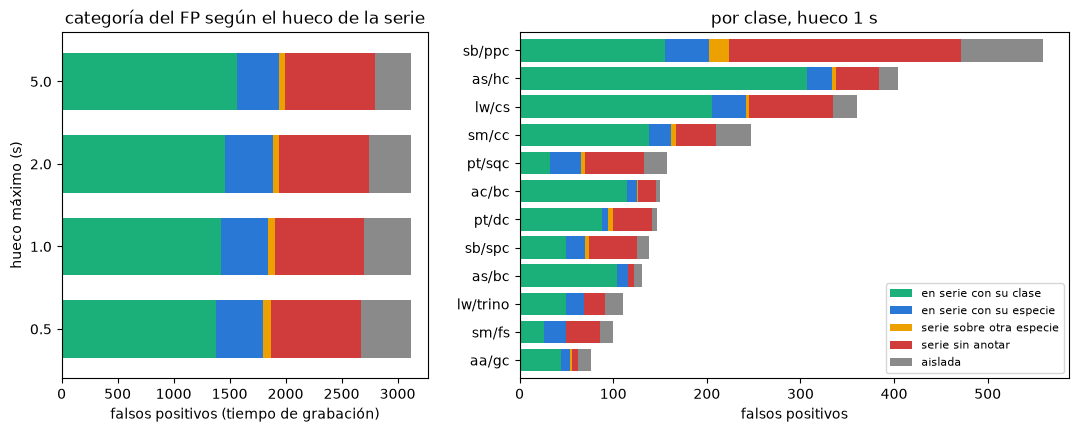

In [11]:
chosen_gap = 1.0
chosen = by_gap[by_gap.hueco == chosen_gap]
per_class_series = pd.crosstab(chosen.clase, chosen["categoría"]).reindex(
    columns=SERIES_CATEGORIES, fill_value=0
)
per_class_series = per_class_series.loc[
    per_class_series.sum(axis=1).sort_values(ascending=False).index[:12]
]

fig, (left, right) = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [2, 3]})
sensitivity.plot.barh(
    stacked=True, ax=left, color=[SERIES_COLORS[c] for c in SERIES_CATEGORIES], width=0.7
)
left.set(xlabel="falsos positivos (tiempo de grabación)", ylabel="hueco máximo (s)")
left.set_title("categoría del FP según el hueco de la serie")
left.get_legend().remove()
per_class_series.iloc[::-1].plot.barh(
    stacked=True, ax=right, color=[SERIES_COLORS[c] for c in SERIES_CATEGORIES], width=0.8
)
right.set(xlabel="falsos positivos", ylabel="")
right.set_title(f"por clase, hueco {chosen_gap:g} s")
right.legend(fontsize=8)
plt.show()

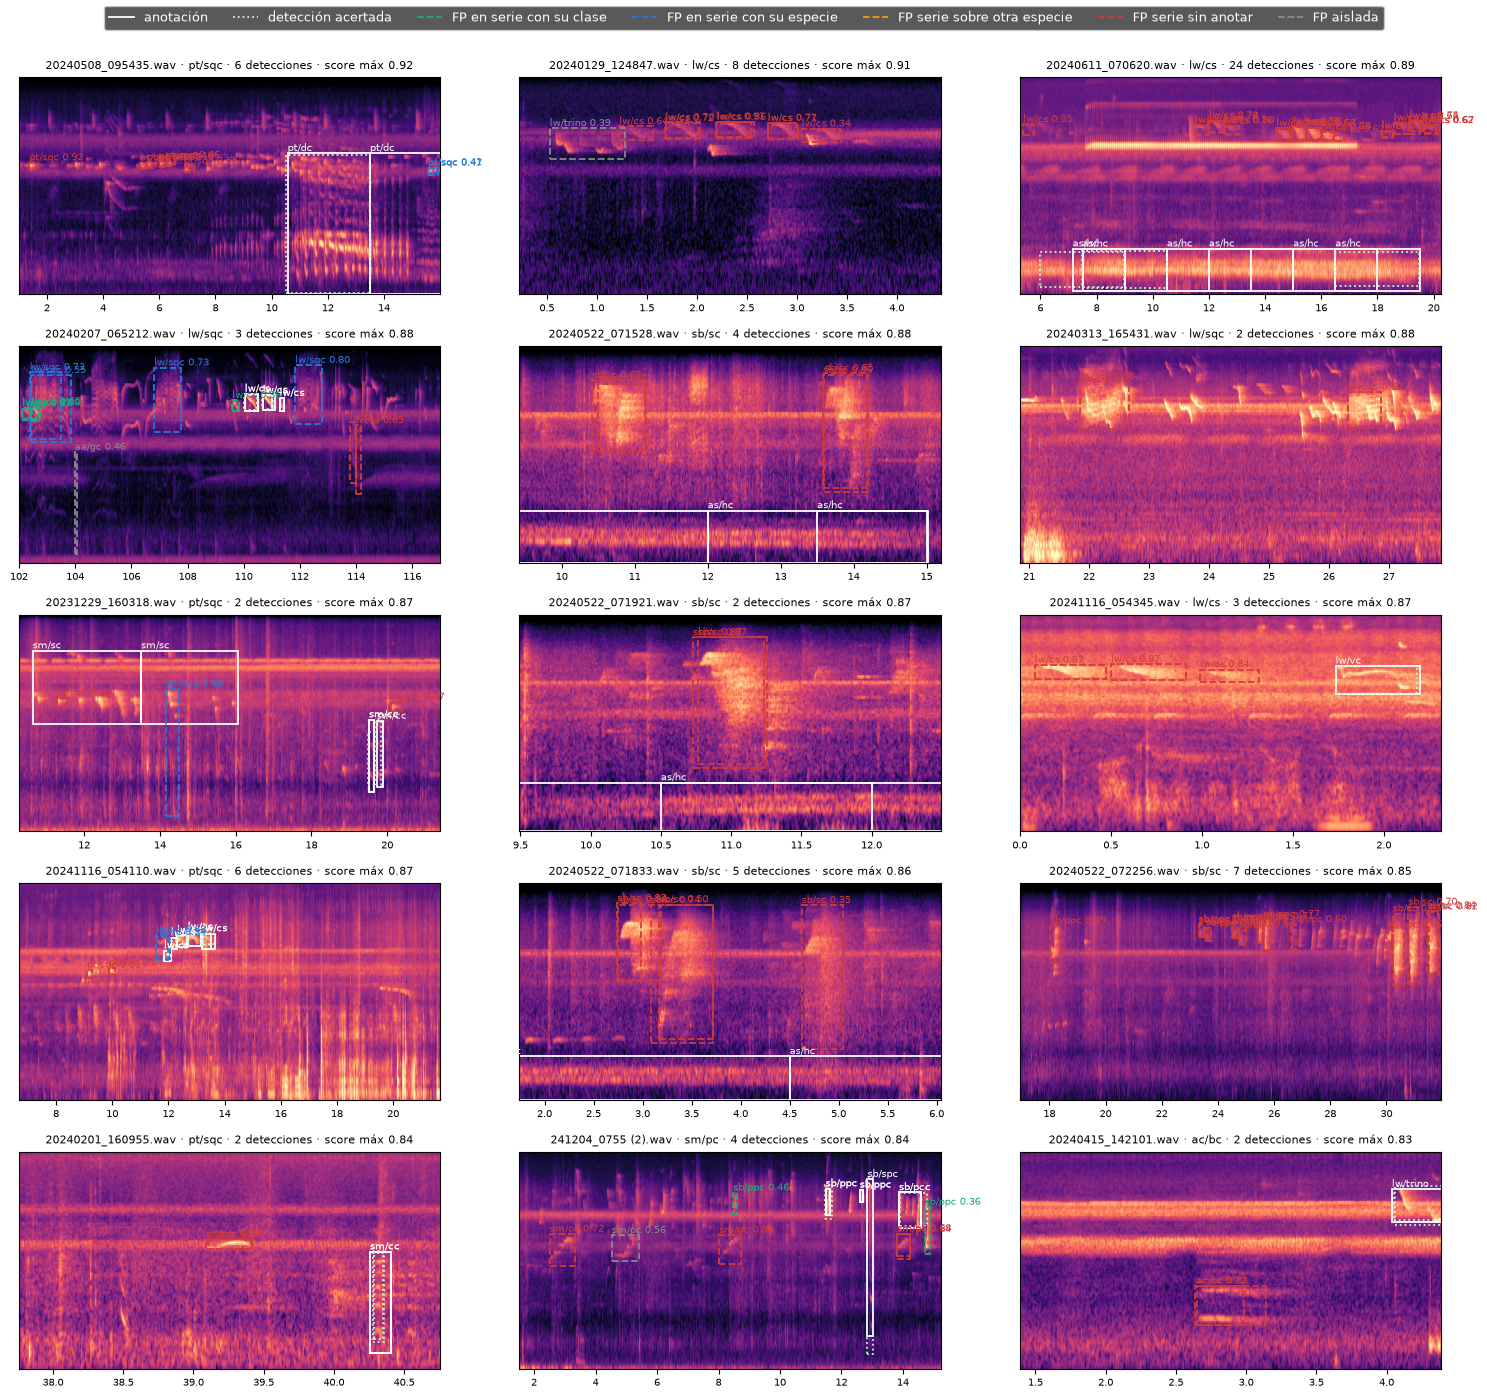

In [12]:
MEL = mel_spectrogram(P)
db_low, db_high = cache.db_range()
series_category_of = dict(zip(chosen["detección"], chosen["categoría"], strict=True))


def load_segment(path: str, start_s: float, stop_s: float) -> tuple[Tensor, float]:
    with soundfile.SoundFile(path) as audio:
        audio.seek(int(start_s * audio.samplerate))
        frames = audio.read(
            int((stop_s - start_s) * audio.samplerate), dtype="float32", always_2d=True
        )
        waveform = torch.from_numpy(frames.mean(axis=1))
        if audio.samplerate != P.target_sr:
            waveform = torchaudio.functional.resample(waveform, audio.samplerate, P.target_sr)
        stop_s = start_s + len(frames) / audio.samplerate
    return mel_to_unit(MEL(waveform), db_low, db_high), stop_s


def rows_in_span(boxes: Boxes, recording: int, start_s: float, stop_s: float) -> list[int]:
    centers = boxes.boxes[:, 0]
    inside = (boxes.image_ids == recording) & (centers >= start_s) & (centers <= stop_s)
    return inside.nonzero().flatten().tolist()


def rectangle_s(ax: Axes, box: Tensor, color: str, style: str, text: str) -> None:
    cx, cy, w, h = box.tolist()
    ax.add_patch(Rectangle((cx - w / 2, cy - h / 2), w, h, fill=False, ec=color, ls=style, lw=1.3))
    ax.text(cx - w / 2, cy + h / 2, text, color=color, fontsize=7, va="bottom")


def draw_segment(ax: Axes, recording: int, start_s: float, stop_s: float) -> None:
    image, stop_s = load_segment(dump.recording_names[recording], start_s, stop_s)
    ax.imshow(image, origin="lower", aspect="auto", cmap="magma", extent=(start_s, stop_s, 0, 1))
    for row in rows_in_span(truth_rec, recording, start_s, stop_s):
        rectangle_s(ax, truth_rec.boxes[row], "white", "-", labels.name(int(truth_rec.labels[row])))
    for row in rows_in_span(detections_rec, recording, start_s, stop_s):
        if found_rec[row]:
            rectangle_s(ax, detections_rec.boxes[row], "#c8f5dc", ":", "")
        else:
            name = labels.name(int(detections_rec.labels[row]))
            color = SERIES_COLORS[series_category_of[row]]
            rectangle_s(
                ax,
                detections_rec.boxes[row],
                color,
                "--",
                f"{name} {float(detections_rec.scores[row]):.2f}",
            )
    ax.set(yticks=[], xlim=(start_s, stop_s))
    ax.tick_params(labelsize=7)


unannotated = chosen[chosen["categoría"] == UNANNOTATED]
series = (
    unannotated.groupby(["grabación", "serie", "clase", "inicio", "fin"])
    .agg(detecciones=("score", "size"), score=("score", "max"))
    .reset_index()
    .sort_values(["score", "detecciones"], ascending=False)
    .drop_duplicates("grabación")
    .head(15)
)
fig, axes = plt.subplots(5, 3, figsize=(15, 14))
for ax, row in zip(axes.flat, series.to_dict("records"), strict=False):
    center = (row["inicio"] + row["fin"]) / 2
    half = min(MAX_SEGMENT_S, max(P.clip_len_s, row["fin"] - row["inicio"] + 2.0)) / 2
    draw_segment(ax, int(row["grabación"]), max(0.0, center - half), center + half)
    recording = int(row["grabación"])
    ax.set_title(
        f"{Path(dump.recording_names[recording]).name} · {row['clase']} · "
        f"{row['detecciones']} detecciones · score máx {row['score']:.2f}",
        fontsize=8,
    )
handles = [
    Line2D([], [], color="white", ls="-", lw=1.3, label="anotación"),
    Line2D([], [], color="#c8f5dc", ls=":", lw=1.3, label="detección acertada"),
    *(
        Line2D([], [], color=SERIES_COLORS[c], ls="--", lw=1.3, label=f"FP {c}")
        for c in SERIES_CATEGORIES
    ),
]
fig.legend(
    handles=handles,
    loc="upper center",
    ncol=len(handles),
    facecolor="#303030",
    labelcolor="white",
    fontsize=9,
)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

In [13]:
def runs_of(boxes: Tensor) -> list[tuple[float, float]]:
    spans = box_convert(boxes, "cxcywh", "xyxy")[:, [0, 2]]
    merged: list[list[float]] = []
    for x0, x1 in spans[spans[:, 0].argsort()].tolist():
        if merged and x0 <= merged[-1][1] + GAP_S / P.clip_len_s:
            merged[-1][1] = max(merged[-1][1], x1)
        else:
            merged.append([x0, x1])
    return [(x0, x1) for x0, x1 in merged]


def count_within(boxes: Tensor, start: float, stop: float) -> int:
    centers = boxes[:, 0]
    return int(((centers >= start) & (centers <= stop)).sum())


def per_run(name: str) -> pd.DataFrame:
    class_id = labels.id(name)
    annotated = truth.select(truth.labels == class_id)
    detected = kept.select(kept.labels == class_id)
    detected_rows = rows_by_image(detected.image_ids)
    margin = GAP_S / P.clip_len_s
    records = []
    for image_id, rows in rows_by_image(annotated.image_ids).items():
        detected_boxes = detected.boxes[detected_rows.get(image_id, [])]
        for start, stop in runs_of(annotated.boxes[rows]):
            records.append(
                {
                    "clase": name,
                    "grabación": dump.recording_names[int(dump.recordings[image_id])],
                    "ventana": image_id,
                    "anotadas": count_within(annotated.boxes[rows], start, stop),
                    "detectadas": count_within(detected_boxes, start - margin, stop + margin),
                }
            )
    return pd.DataFrame(records)


runs = pd.concat([per_run(name) for name in SYLLABLES], ignore_index=True)
runs["sin anotar"] = (runs.detectadas - runs.anotadas).clip(lower=0)
runs.groupby("clase").agg(
    rachas=("ventana", "size"),
    sílabas_anotadas=("anotadas", "sum"),
    sílabas_detectadas=("detectadas", "sum"),
    detectadas_de_más=("sin anotar", "sum"),
    rachas_con_más_detectadas=("sin anotar", lambda s: int((s > 0).sum())),
)

,rachas,sílabas_anotadas,sílabas_detectadas,detectadas_de_más,rachas_con_más_detectadas
clase,,,,,
lw/cs,358,1000,970,96,83
sm/fs,83,298,188,10,9


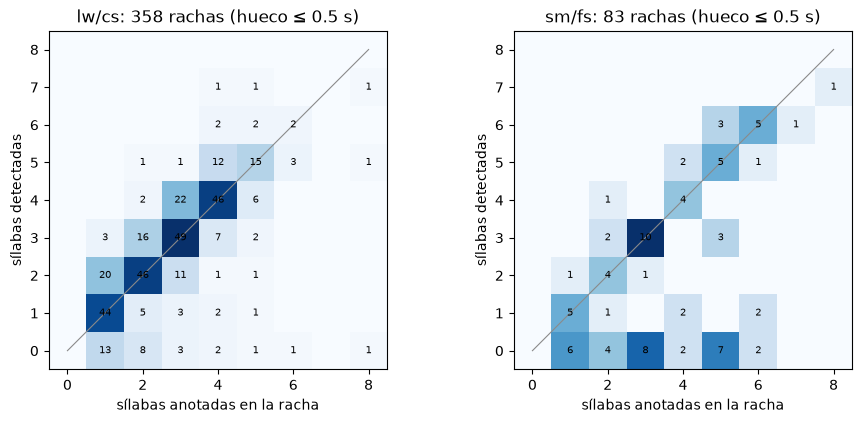

In [14]:
fig, axes = plt.subplots(1, len(SYLLABLES), figsize=(11, 4.4))
for ax, name in zip(axes, SYLLABLES, strict=True):
    table = runs[runs.clase == name]
    limit = int(max(table.anotadas.max(), table.detectadas.max())) + 1
    counts = pd.crosstab(table.detectadas, table.anotadas).reindex(
        index=range(limit), columns=range(limit), fill_value=0
    )
    ax.imshow(counts.to_numpy(), origin="lower", cmap="Blues")
    for (i, j), n in np.ndenumerate(counts.to_numpy()):
        if n:
            ax.text(j, i, str(n), ha="center", va="center", fontsize=7)
    ax.plot([0, limit - 1], [0, limit - 1], color="#8a8a8a", lw=0.8)
    ax.set(xlabel="sílabas anotadas en la racha", ylabel="sílabas detectadas")
    ax.set_title(f"{name}: {len(table)} rachas (hueco ≤ {GAP_S} s)")
plt.show()

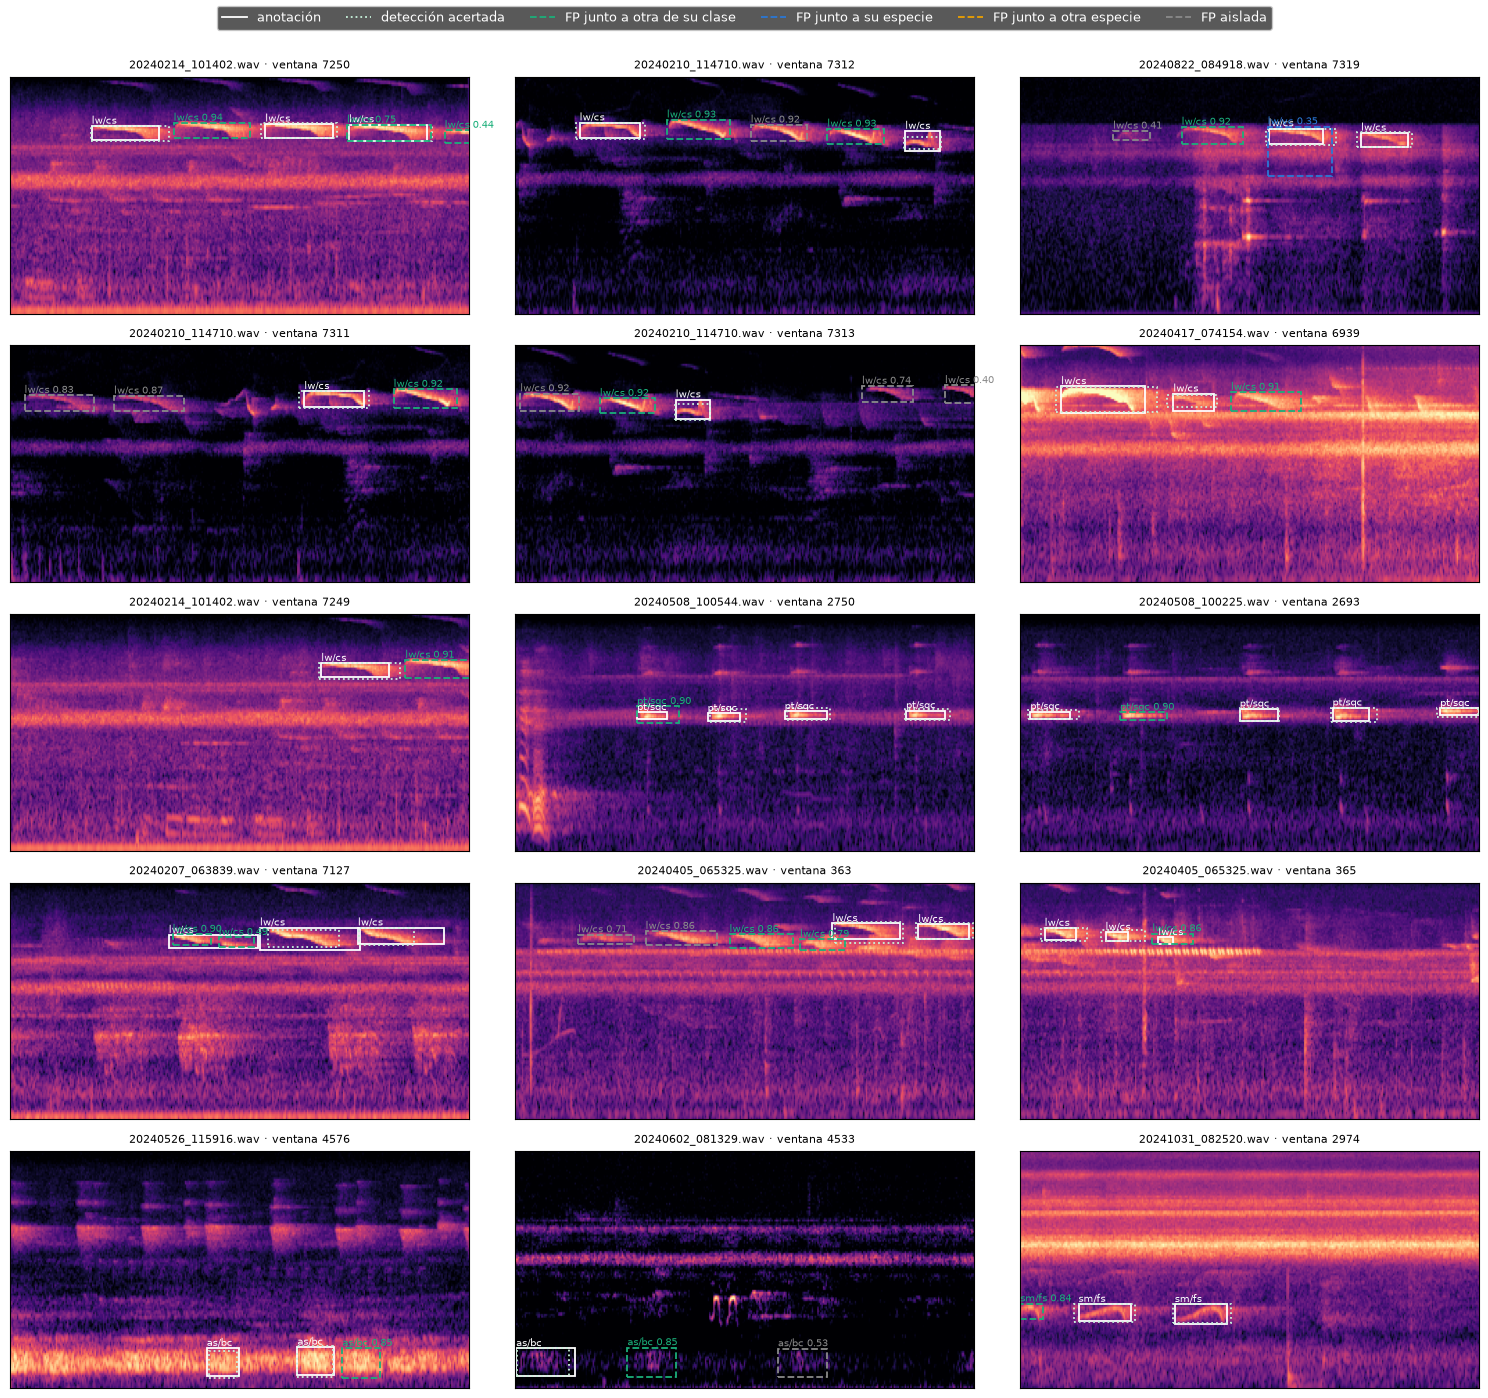

In [15]:
windows = torch.load(cache.split_path(cache.VAL), map_location="cpu", weights_only=False, mmap=True)
category_of_row = dict(zip(audit.fila, audit["categoría"], strict=True))


def rectangle(ax: Axes, box: Tensor, color: str, style: str, text: str) -> None:
    cx, cy, w, h = box.tolist()
    x0 = (cx - w / 2) * P.clip_len_s
    ax.add_patch(
        Rectangle((x0, cy - h / 2), w * P.clip_len_s, h, fill=False, ec=color, ls=style, lw=1.3)
    )
    ax.text(x0, cy + h / 2, text, color=color, fontsize=7, va="bottom")


def draw_window(ax: Axes, image_id: int) -> None:
    image = mel_to_unit(windows["images"][image_id][0], db_low, db_high)
    ax.imshow(image, origin="lower", aspect="auto", cmap="magma", extent=(0, P.clip_len_s, 0, 1))
    for row in (truth.image_ids == image_id).nonzero().flatten().tolist():
        rectangle(ax, truth.boxes[row], "white", "-", labels.name(int(truth.labels[row])))
    for row in (kept.image_ids == image_id).nonzero().flatten().tolist():
        if found[row]:
            rectangle(ax, kept.boxes[row], "#c8f5dc", ":", "")
        else:
            name = labels.name(int(kept.labels[row]))
            color = COLORS[category_of_row[row]]
            rectangle(ax, kept.boxes[row], color, "--", f"{name} {float(kept.scores[row]):.2f}")
    ax.set(xticks=[], yticks=[])


examples = audit[audit["categoría"] == NEARBY].sort_values("score", ascending=False)
examples = examples.drop_duplicates("ventana").head(15)
fig, axes = plt.subplots(5, 3, figsize=(15, 14))
for ax, (_, example) in zip(axes.flat, examples.iterrows(), strict=False):
    draw_window(ax, int(example.ventana))
    ax.set_title(f"{Path(example['grabación']).name} · ventana {example.ventana}", fontsize=8)
handles = [
    Line2D([], [], color="white", ls="-", lw=1.3, label="anotación"),
    Line2D([], [], color="#c8f5dc", ls=":", lw=1.3, label="detección acertada"),
    *(Line2D([], [], color=COLORS[c], ls="--", lw=1.3, label=f"FP {c}") for c in CATEGORIES),
]
fig.legend(
    handles=handles,
    loc="upper center",
    ncol=len(handles),
    frameon=True,
    facecolor="#303030",
    labelcolor="white",
    fontsize=9,
)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()